In [1]:
import mujoco
from IPython.display import clear_output
import math
import time
import jax
import jax.numpy as jp
from mujoco_playground._src.locomotion.pendulum_inverse_pendulum.environment import DoublePendulumEnv
import random

In [2]:

model = mujoco.MjModel.from_xml_path(
    "mujoco_playground/mujoco_playground/_src/locomotion/pendulum_inverse_pendulum/xmls/pendulum_inverse_pendulum.xml"
)
print(model.nq, model.nv, model.nu)  # should print your joint/actuator counts

2 2 1


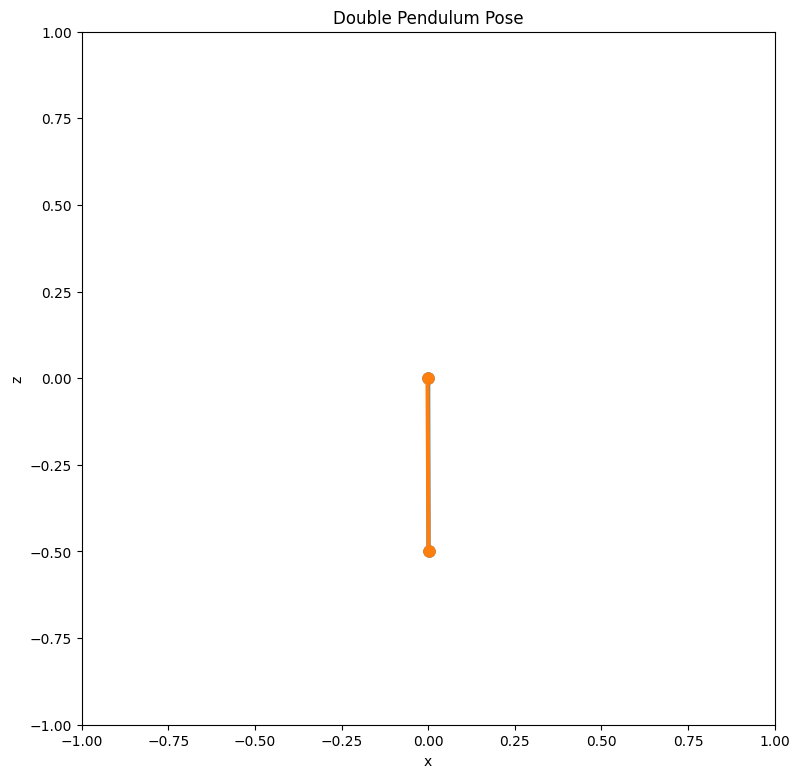

Step 300, reward: 0.9000, angles: [-0.01691588 -3.1375692   0.10747812 -0.03522237],  [0.0241262]
✓ 300 steps completed, mean reward: 0.8985


In [3]:
frames = []
states = []

# 1. Create the environment



env = DoublePendulumEnv(config_overrides={"task": "balance"})
#env = DoublePendulumEnv(config_overrides={"task": "swingup"})
print("✓ Environment created")
print(f"  action_size: {env.action_size}")
print(f"  xml_path: {env.xml_path}")
print(f"env._config.task: {env._config.task}")

# 2. Test reset
rng = jax.random.PRNGKey(random.randint(0,99999999))
#rng = jax.random.PRNGKey(0)

state = env.reset(rng)
print("\n✓ Reset successful")
print(f"  obs shape:    {state.obs.shape}")       # should be (6,)
print(f"  reward:       {state.reward}")          # should be 0.0
print(f"  done:         {state.done}")            # should be 0.0



k=0.1
I = 1
D = 0
fist_joint_dependancy = 0.3
setpoint_change = 0.0
position_setpoint = jp.array([0.0+setpoint_change, -math.pi-setpoint_change])  # target angles for the pendulum
pos_diference_Integration = jp.zeros((2,))
vel_diference_last = jp.zeros((2,))
diference_array = []
# 4. Test a full rollout
steps = 300

print(f"\nRunning {steps} steps...")
for i in range(steps):
    rng, action_rng = jax.random.split(rng)
    #action = jax.random.uniform(action_rng, (env.action_size,), minval=-1.0, maxval=1.0)
    #action = jp.ones((env.action_size,))
    
    pos_diference = position_setpoint - state.obs[:2]
    diference_array.append(pos_diference.tolist())
    



    pos_diference_Integration += pos_diference
    velocity_setpoint = +k*(pos_diference +  I*pos_diference_Integration+ D*vel_diference_last)

    vel_diference = velocity_setpoint - state.obs[2:4]
    vel_deriv = vel_diference-vel_diference_last
    acceleration_setpoint = k*(vel_diference*k + I*pos_diference+ D*vel_deriv) # cant use D  velocity too noisy
    vel_diference_last = vel_diference

    """
    if i <= 10:
        acceleration_setpoint = 0.06*jp.ones((env.action_size,))
    elif i <= 25 :
        acceleration_setpoint = -0.06*jp.ones((env.action_size,))
    elif i <= 48:
        acceleration_setpoint = jp.zeros((env.action_size,))
    elif i <= 63:
        acceleration_setpoint = -0.03*jp.ones((env.action_size,))
    elif i <= 75:
        acceleration_setpoint = jp.zeros((env.action_size,))
    
      
        
        
    """
        
        

    

    action = 0.3/(k**2)*jp.ones((env.action_size,))*(acceleration_setpoint[1] + fist_joint_dependancy * acceleration_setpoint[0])
    state = env.step(state, action)
    states.append(state)
    
    clear_output(wait=True)

    frames.append(env.simple_render(state))
    print(f"Step {i+1}, reward: {state.reward:.4f}, angles: {state.obs[:4]},  {action}")
    #time.sleep(1)

print(f"✓ {steps} steps completed, mean reward: {sum([float(state.reward) for state in states])/len(states):.4f}")

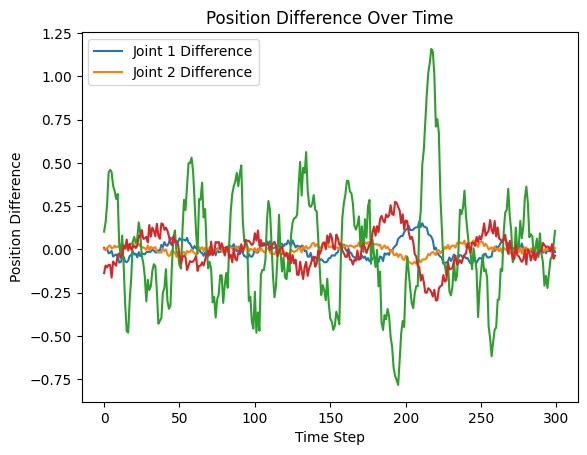

total reward: 269.5641866326332


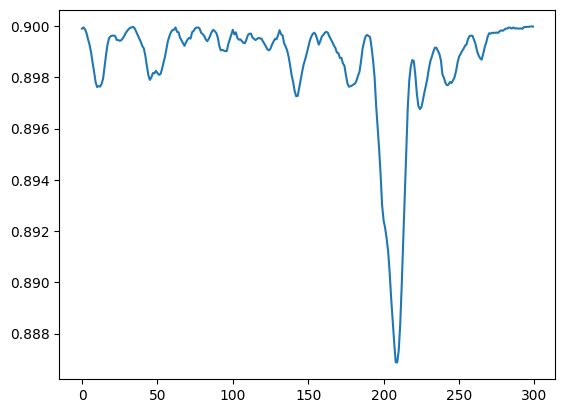

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt




sns.lineplot(x=range(len(diference_array)), y=[d[0] for d in diference_array], label="Joint 1 Difference")
sns.lineplot(x=range(len(diference_array)), y=[d[1] for d in diference_array], label="Joint 2 Difference")
sns.lineplot(x=range(len(states)), y = [float(state.obs[2]) for state in states] )
sns.lineplot(x=range(len(states)), y = [float(state.obs[3]) for state in states] )
plt.xlabel("Time Step")
plt.ylabel("Position Difference")
plt.title("Position Difference Over Time")
plt.legend()
plt.show()

sns.lineplot(x=range(len(states)), y=[float(state.reward) for state in states])
print("total reward:",sum([float(state.reward) for state in states]))

In [5]:
import numpy as np
import imageio.v2 as imageio
from IPython.display import Video, display

if not frames:
    raise ValueError("No frames captured yet. Run the rollout cell first.")

def to_rgb_frame(frame):
    if hasattr(frame, "figure"):
        figure = frame.figure
        figure.canvas.draw()
        return np.asarray(figure.canvas.buffer_rgba())[..., :3].copy()

    frame_array = np.asarray(frame)
    if frame_array.ndim == 2:
        return np.repeat(frame_array[..., None], 3, axis=2)
    if frame_array.ndim == 3:
        return frame_array
    raise ValueError(f"Unsupported frame shape: {frame_array.shape}")

video_frames = np.stack([to_rgb_frame(frame) for frame in frames], axis=0)
imageio.mimwrite("pendulum.mp4", video_frames, fps=50, codec="libx264")
display(Video("pendulum.mp4", embed=True))

/usr/local/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(
